# Agentic Frameworks: CrewAI and LangGraph

## Introduction

Agentic frameworks are revolutionizing AI by providing the structure for autonomous systems. They enable AI agents to collaborate and tackle complex tasks without constant human intervention.

**Key Concepts:**

* **Autonomy:** Agents make decisions based on context and reasoning.
* **Collaboration:** Agents work together using defined protocols.
* **Modular Design:** Frameworks offer reusable components and workflows.

**Why are they important?**

* They extend LLM capabilities by connecting them to diverse data and tools.
* They streamline AI development with pre-built structures.
* They enable complex AI solutions beyond single LLM limitations.

## Exploring Agentic Frameworks

Many frameworks exist, including:

* **CrewAI:** Focuses on role-based agent collaboration.
* **LangGraph:** Uses graph-based architecture for complex workflows.
* AutoGen, LangChain, MetaGPT, etc.

We will focus on CrewAI and LangGraph.

### CrewAI

**Overview:**

* Designed for orchestrating autonomous, role-playing AI agents.
* Organizes agents into "Crews" with specific roles and goals.
* Uses "Tasks" and "Processes" to define work and collaboration patterns.
* "Flows" offer more granular control.

**Key Features:**

* Role-based agents with defined expertise.
* Flexible tool and API integrations.
* Intelligent collaboration and coordination.
* Sequential and parallel workflow support.
* Human-in-the-loop workflows, monitoring and tracking.

**Advantages:**

* Simple to use, yet offers low-level control.
* Autonomous agents mimicking human teamwork.
* Extensible and production-ready.
* Independent of LangChain, streamlined API.

**Limitations:**

* Complexity increases with many agents.
* Time-consuming initial setup.
* Potential scalability challenges.
* Limited customization compared to some frameworks.
* Does not currently support streaming function calls, or as many custom models.

**Use Cases:**

* Content creation, customer service, business analysis.
* Healthcare, finance, manufacturing, HR, smart homes, autonomous vehicles.
* Research, data analysis.

### LangGraph

**Overview:**

* Built on LangChain, using a graph-based architecture.
* Focuses on control and reliability for complex tasks.
* Uses nodes (agents/chains) and edges (communication).
* Automatic state management, and cyclical graphs.

**Key Features:**

* Controllable cognitive architectures.
* Moderation and quality loops.
* Built-in statefulness.
* Real-time streaming support.
* Integration with LangGraph Platform and Studio.
* Modular components, task chaining.

**Advantages:**

* Simplified development with flexibility and scalability.
* Control, moderation, and human intervention.
* State persistence and real-time feedback.
* Graph-based workflows for complex relationships.
* Strong debugging and observability.

**Limitations:**

* Requires predefined workflow paths, limiting autonomy.
* Lacks native autonomous goal setting.
* Complex setup and steep learning curve.
* Potential for loops and redundant processing.
* Rigid state management.

**Use Cases:**

* Sophisticated chatbots, robotics, autonomous vehicles.
* Social network analysis, fraud detection, RAG systems.
* Code generation.

## Comparative Analysis: CrewAI vs. LangGraph

| Feature           | CrewAI                                      | LangGraph                                               |
| :---------------- | :------------------------------------------ | :------------------------------------------------------ |
| **Core Philosophy** | Role-based collaboration                    | Graph-based orchestration                               |
| **Agent Definition** | Roles, goals, tools                        | Nodes with defined states                               |
| **Workflow** | Crews, Flows                                | Graph (nodes, edges)                                    |
| **State Management** | Framework-managed                           | Developer-managed                                       |
| **Flexibility** | Opinionated, less customizable              | Highly customizable                                     |
| **Ease of Use** | Easier for beginners                         | Steeper learning curve                                  |
| **Scalability** | Designed for multi-agent systems            | Moderate for very large systems                         |
| **Ecosystem** | Standalone                                  | LangChain integration                                   |
| **Use Cases** | Content, teams, research                    | NLP, complex pipelines, code generation                 |

## General Benefits and Drawbacks

**Benefits:**

* Simplified development and faster prototyping.
* Built-in communication and planning.
* Monitoring, debugging, and scalability.
* Modularity and reusability.

**Drawbacks:**

* Abstraction can obscure details.
* Dependency on the framework.
* Limited customization.
* Potential overhead for simple tasks.
* Challenges with state management and tool calls.

## Conclusion

* Choose CrewAI for collaborative tasks and ease of use.
* Choose LangGraph for complex, stateful workflows and control.
* Understand the benefits and drawbacks before implementation.
* Agentic Frameworks are a rapidly evolving area of AI.
* Start simple, use documentation, and iterate.

# The Simplest Graph

Let's build a simple graph with 3 nodes and one conditional edge.

![Screenshot 2024-08-20 at 3.11.22 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dba5f465f6e9a2482ad935_simple-graph1.png)

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langgraph

## State

First, define the [State](https://langchain-ai.github.io/langgraph/concepts/low_level/#state) of the graph.

The State schema serves as the input schema for all Nodes and Edges in the graph.

Let's use the `TypedDict` class from python's `typing` module as our schema, which provides type hints for the keys.

In [ ]:
from typing_extensions import TypedDict

class State(TypedDict):
    graph_state: str


## Nodes

[Nodes](https://langchain-ai.github.io/langgraph/concepts/low_level/#nodes) are just python functions.

The first positional argument is the state, as defined above.

Because the state is a `TypedDict` with schema as defined above, each node can access the key, `graph_state`, with `state['graph_state']`.

Each node returns a new value of the state key `graph_state`.
  
By default, the new value returned by each node [will override](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers) the prior state value.

In [ ]:
def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] +" I am"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] +" happy!"}

def node_3(state):
    print("---Node 3---")
    return {"graph_state": state['graph_state'] +" sad!"}

## Edges

[Edges](https://langchain-ai.github.io/langgraph/concepts/low_level/#edges) connect the nodes.

Normal Edges are used if you want to *always* go from, for example, `node_1` to `node_2`.

[Conditional Edges](https://langchain-ai.github.io/langgraph/concepts/low_level/#conditional-edges) are used if you want to *optionally* route between nodes.

Conditional edges are implemented as functions that return the next node to visit based upon some logic.

In [ ]:
import random
from typing import Literal

def decide_mood(state) -> Literal["node_2", "node_3"]:

    # Often, we will use state to decide on the next node to visit
    user_input = state['graph_state']

    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:

        # 50% of the time, we return Node 2
        return "node_2"

    # 50% of the time, we return Node 3
    return "node_3"

## Graph Construction

Now, we build the graph from our [components](
https://langchain-ai.github.io/langgraph/concepts/low_level/) defined above.

The [StateGraph class](https://langchain-ai.github.io/langgraph/concepts/low_level/#stategraph) is the graph class that we can use.

First, we initialize a StateGraph with the `State` class we defined above.

Then, we add our nodes and edges.

We use the [`START` Node, a special node](https://langchain-ai.github.io/langgraph/concepts/low_level/#start-node) that sends user input to the graph, to indicate where to start our graph.

The [`END` Node](https://langchain-ai.github.io/langgraph/concepts/low_level/#end-node) is a special node that represents a terminal node.

Finally, we [compile our graph](https://langchain-ai.github.io/langgraph/concepts/low_level/#compiling-your-graph) to perform a few basic checks on the graph structure.

We can visualize the graph as a [Mermaid diagram](https://github.com/mermaid-js/mermaid).

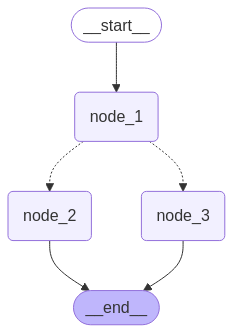

In [ ]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

## Graph Invocation

The compiled graph implements the [runnable](https://python.langchain.com/docs/concepts/runnables/) protocol.

This provides a standard way to execute LangChain components.

`invoke` is one of the standard methods in this interface.

The input is a dictionary `{"graph_state": "Hi, this is lance."}`, which sets the initial value for our graph state dict.

When `invoke` is called, the graph starts execution from the `START` node.

It progresses through the defined nodes (`node_1`, `node_2`, `node_3`) in order.

The conditional edge will traverse from node `1` to node `2` or `3` using a 50/50 decision rule.

Each node function receives the current state and returns a new value, which overrides the graph state.

The execution continues until it reaches the `END` node.

In [ ]:
graph.invoke({"graph_state" : "Hi, this is Mehdi."})

---Node 1---
---Node 3---


{'graph_state': 'Hi, this is Mehdi. I am sad!'}

In [ ]:
!pip install -qU langchain-openai langgraph

In [ ]:
from  langchain_core.output_parsers import StrOutputParser

In [ ]:
from langgraph.graph import StateGraph, END, START
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.prompts import MessagesPlaceholder
from typing import List, TypedDict
from  langchain_core.output_parsers import StrOutputParser

In [ ]:



class SentimentAnalyser(BaseModel):
    '''Identifying information about news sentiment.'''
    sentiment: str = Field(..., description="The sentiment of news, only can be one of [neutral, positive, negative]")
    reasoning: str = Field(..., description="Return the reasoning behind your decisions")

class Judge(BaseModel):
    '''Assessment of agreement between the advisor's and the analyst's views on the stock as reflected in the analyzed news.'''
    agreement: str = Field(..., description="Specifies if the advisor agrees with the provided sentiment or not. Possible values are [yes, no].")
    reasoning: str = Field(..., description="Return the reasoning behind the agreement or disagreement")

# Define models


In [ ]:
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get('openai_api_key')
llm = ChatOpenAI(model="gpt-4o-mini")


In [ ]:
# Define prompts
sentiment_prompt = ChatPromptTemplate.from_messages([
    ("system", """
    Perform a sentiment analysis on the provided news about {stock}.
    Perform a sentiment analysis on the provided news. Focus solely on the sentiment reflected only
    by the terms related to the influence of the news on the rising or declining price of the {stock},
     while disregarding any other irrelevant information such as historical events, social aspects,
      or unrelated congratulatory or condolences messages.
            News: {text}
            stock: {stock}
            Please 'ONLY' output 'one' sentiment from [Positive / Neutral / Negative ] alongside the reasoning.
    """),
    MessagesPlaceholder(variable_name="messages")
])

reflection_prompt = ChatPromptTemplate.from_messages([
    ("system", """
    Your task is to review the sentiment analysis results for the news article about {stock}.
    1. Assess whether the sentiment (Positive, Neutral, or Negative) accurately reflects the impact of the news on the stock's price movement.
    2. Ensure the sentiment analysis considers only factors relevant to the stock's price movement, disregarding any irrelevant details like historical events or social aspects.
    3. Clearly mention that you agree or disagree with the sentiment analysis results for {stock} and your opinion.
    Please note:
    - Sentiment must be one of the following: Positive, Neutral, or Negative. It cannot be undetermined.
    - Specify your agreement or disagreement solely with the sentiment, not its reasoning.
    - Ensure the sentiment analysis is based solely on the price movement of {stock}.
    News: {text}
    Stock: {stock}
    """),
    MessagesPlaceholder(variable_name="messages")
])


In [ ]:
generate_chain = sentiment_prompt | llm | StrOutputParser()

reflect_chain = reflection_prompt | llm.with_structured_output(Judge)

# Graph definition
class GraphState(TypedDict):
    iteration: int
    sentiment: str
    agreement: str
    messages: List
    stock_name: str
    news_text: str


In [ ]:
del graph

In [ ]:


def generate_sentiment(state):
    state['iteration'] += 1
    response = generate_chain.invoke(
        {"messages": state["messages"], "stock": state['stock_name'],
         "text": state['news_text']})
    # state['sentiment'] =
    print(response)
    state['messages'].append(('ai', response)) #AIMessage, HumanMessage(content='njkljf')
    # print('new message is:', ('ai', response))
    print('state message', state['messages'])
    return state

In [ ]:


def reflect_sentiment(state):
    reflection_input = {
        "messages": state["messages"],
        "stock": state['stock_name'],
        "text": state['news_text'],
    }
    response = reflect_chain.invoke(reflection_input)
    state['agreement'] = response.agreement
    state['messages'].append(
        HumanMessage(content=f"""The sentiment analysis for {state['stock_name']}
                     resulted in an agreement status of '{response.agreement}'.
                     Here is the reasoning provided: {response.reasoning}"""))
    # state['agreement'] = response.agreement
    return state



In [ ]:
def should_continue(state):
    if state['agreement'] == 'yes' or state['iteration'] >= state.get("max_iterations", 5):
        return END
    return "generate_sentiment"

In [ ]:


# Add nodes
graph = StateGraph(GraphState)
graph.add_node("generate_sentiment", generate_sentiment)
graph.add_node("reflect_sentiment", reflect_sentiment)

# Define flow
graph.add_edge(START, "generate_sentiment")

graph.add_edge("generate_sentiment", "reflect_sentiment")
graph.add_conditional_edges("reflect_sentiment", should_continue, {
    END: END,
    "generate_sentiment": "generate_sentiment"
})

# Compile graph
app = graph.compile()

# Invocation




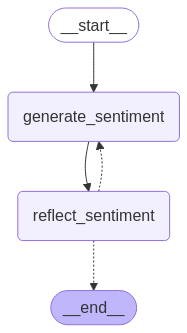

In [ ]:
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:

text= """شرکت جهان فولاد سیرجان از تغییر اعضای هیات مدیره خبر داد.
کد خبر : ۲۷۷۸۸۵
به گزارش بورس نیوز، شرکت جهان فولاد سیرجان از تغییر اعضای هیات مدیره خبر داد.

بر اساس این گزارش، باستناد مصوبۀ مجمع عمومی عادی مورخ ۱۴۰۱/۰۲/۱۰ و جلسۀ هیئت مدیرۀ مورخ ۱۴۰۲/۱۰/۰۳ اسامی اعضای هیئت مدیره و نمایندگان آن‌ها تغییر یافته است."""
stock = "فجهان"

initial_state = {
    "messages":[],
    "iteration": 0,
    "max_iterations": 5,
    "stock_name": stock,
    "news_text": text
}

In [ ]:
final_state = app.invoke(initial_state)


Neutral

The news about the تغییر اعضای هیات مدیره (change of board members) does not provide explicit indications of either a positive or negative influence on the stock price of فجهان. It simply reports a change without mentioning any potential impacts on the company's performance or financial situation. Therefore, the sentiment can be classified as neutral.
state message [('ai', "Neutral\n\nThe news about the تغییر اعضای هیات مدیره (change of board members) does not provide explicit indications of either a positive or negative influence on the stock price of فجهان. It simply reports a change without mentioning any potential impacts on the company's performance or financial situation. Therefore, the sentiment can be classified as neutral.")]


In [ ]:
final_state

{'iteration': 1,
 'agreement': 'yes',
 'messages': [('ai',
   "Neutral\n\nThe news about the تغییر اعضای هیات مدیره (change of board members) does not provide explicit indications of either a positive or negative influence on the stock price of فجهان. It simply reports a change without mentioning any potential impacts on the company's performance or financial situation. Therefore, the sentiment can be classified as neutral."),
  HumanMessage(content="The sentiment analysis for فجهان\n                     resulted in an agreement status of 'yes'.\n                     Here is the reasoning provided: The news regarding the change of board members for فجهان does not imply any significant impact on the stock's price movement, thus justifying a neutral sentiment assessment.", additional_kwargs={}, response_metadata={})],
 'stock_name': 'فجهان',
 'news_text': 'شرکت جهان فولاد سیرجان از تغییر اعضای هیات مدیره خبر داد.\nکد خبر : ۲۷۷۸۸۵\nبه گزارش بورس نیوز، شرکت جهان فولاد سیرجان از تغییر اعضای